# Import libraries and Load Dataset

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
# Load the dataset
df = pd.read_csv(r"C:\Users\User\Downloads\Mall_Customers (1).csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Univariate Analysis

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


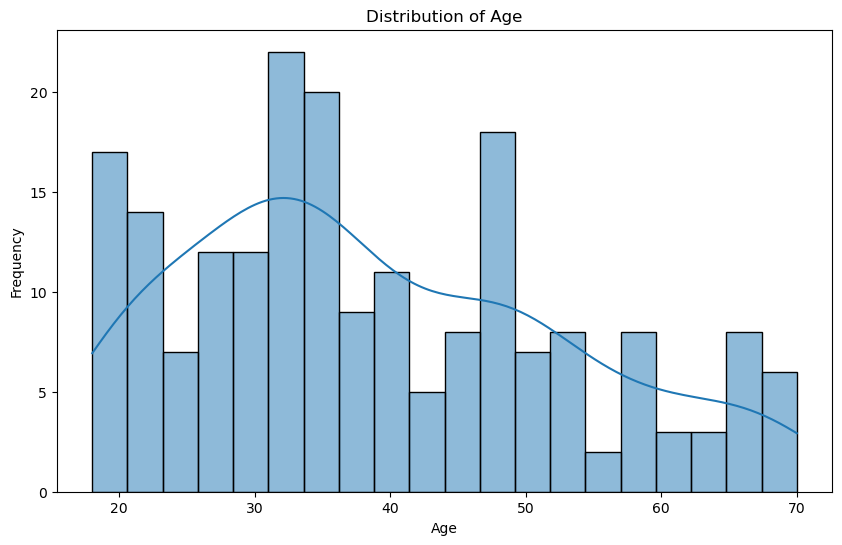

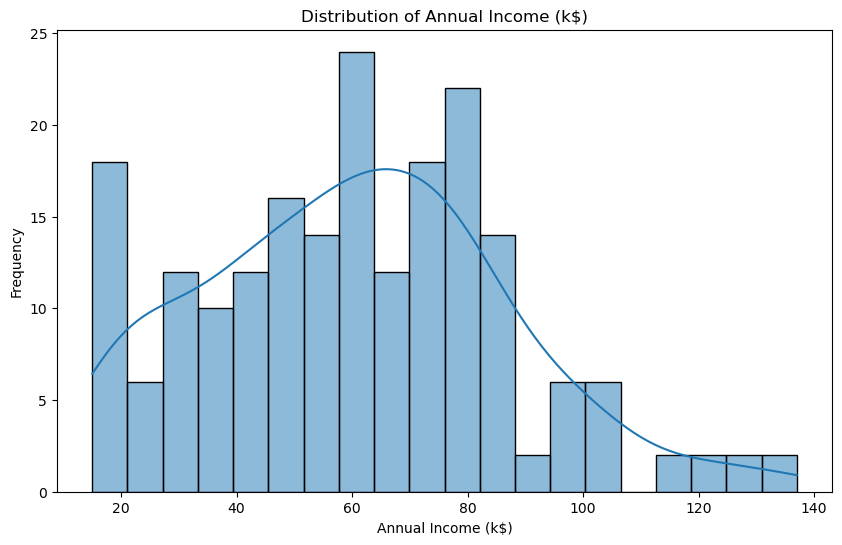

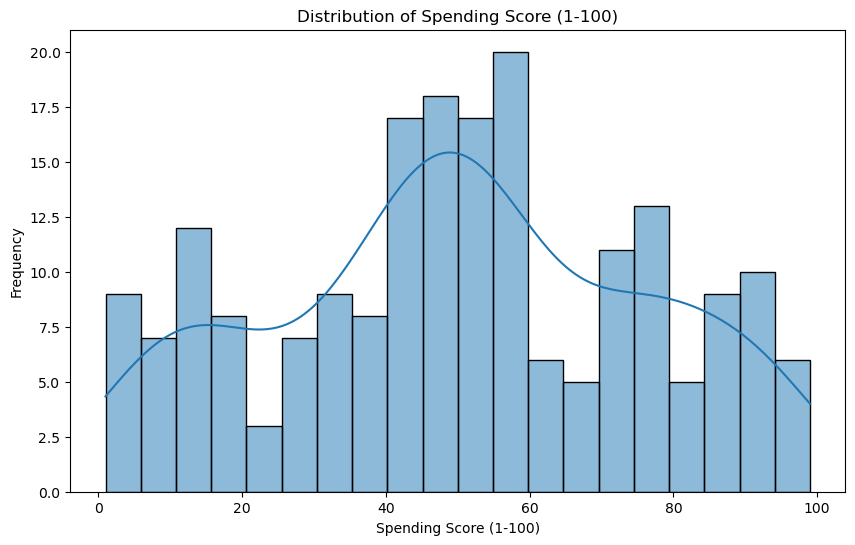

In [8]:
# Plot distribution of Age Annual Income & Spending Score
columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in columns:
  plt.figure(figsize=(10, 6))
  sns.histplot(df[i], bins=20, kde=True)
  plt.title(f'Distribution of {i}')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.show()

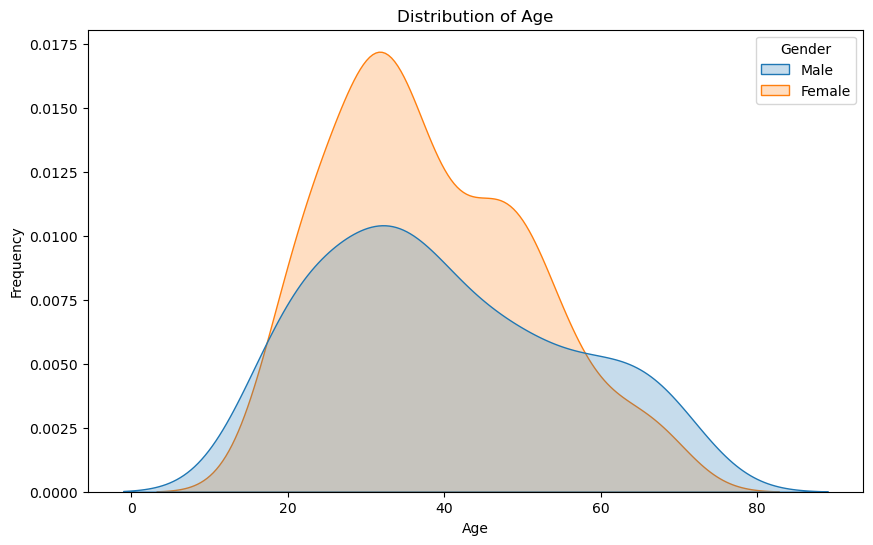

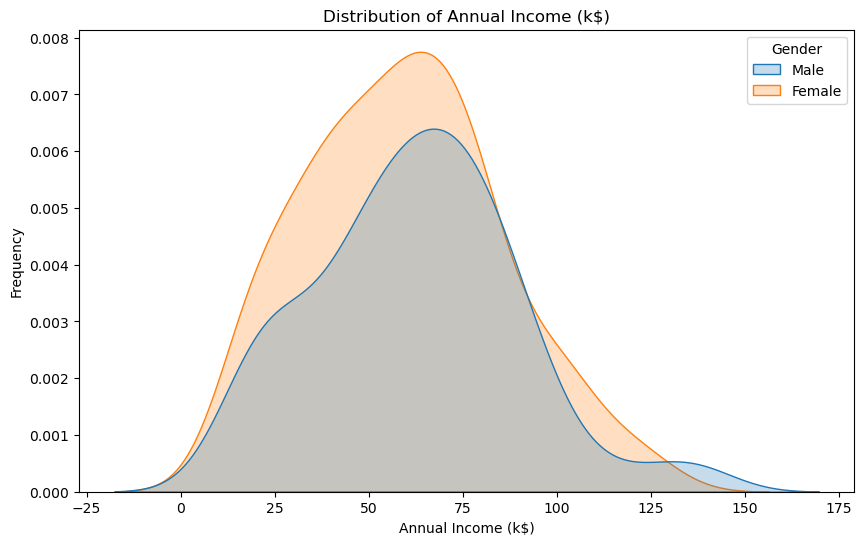

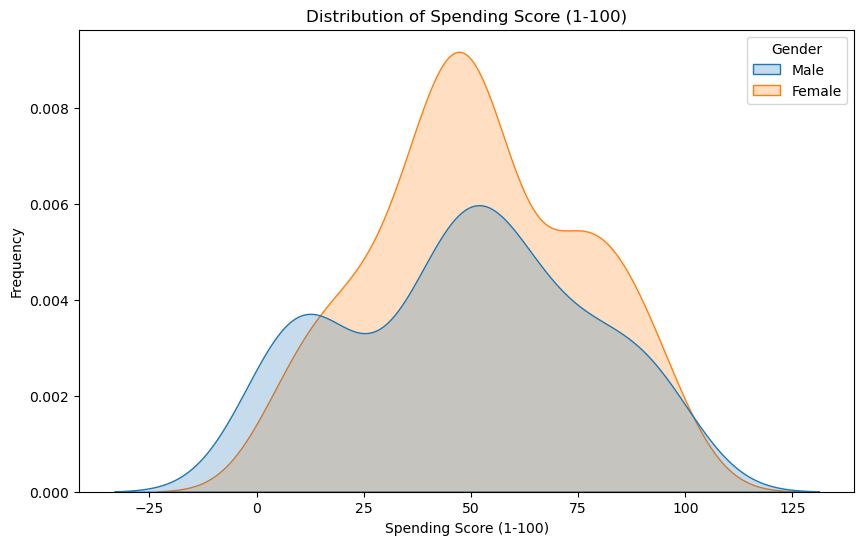

In [52]:
# Plot kde distribution of numerical columns
columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in columns:
  plt.figure(figsize=(10, 6))
  sns.kdeplot(x=df[i], shade=True, hue = df['Gender'])
  plt.title(f'Distribution of {i}')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.show()

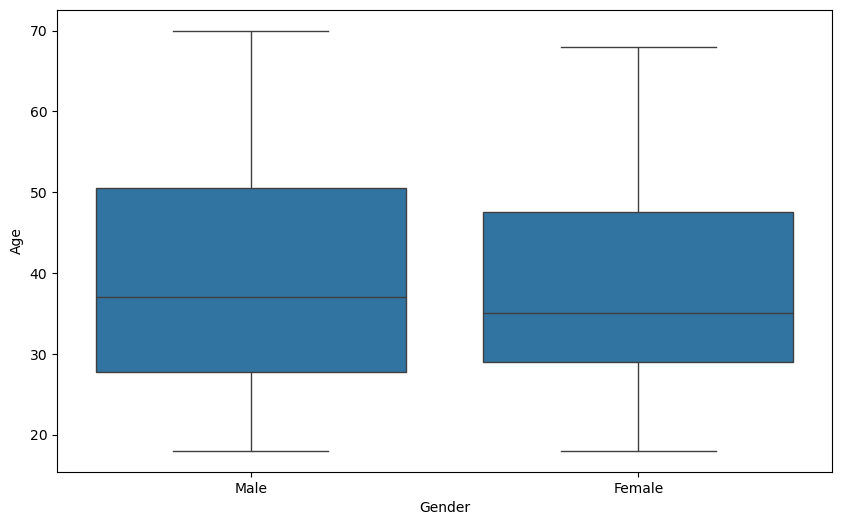

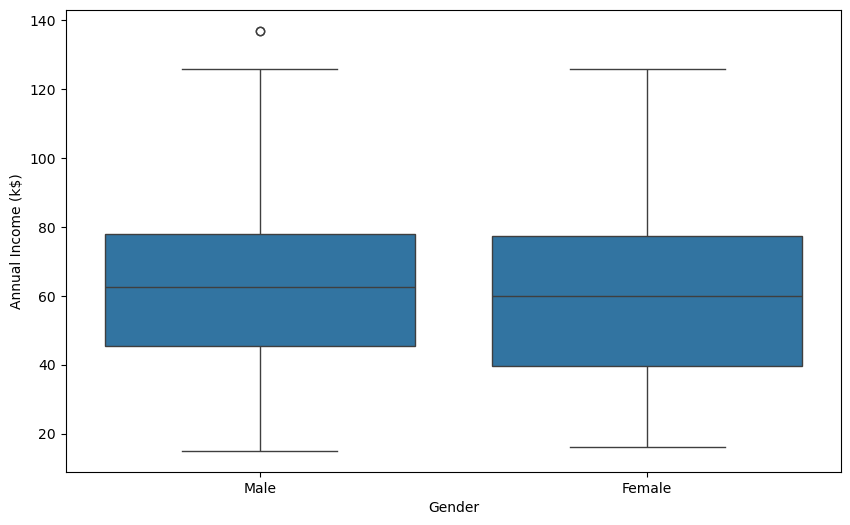

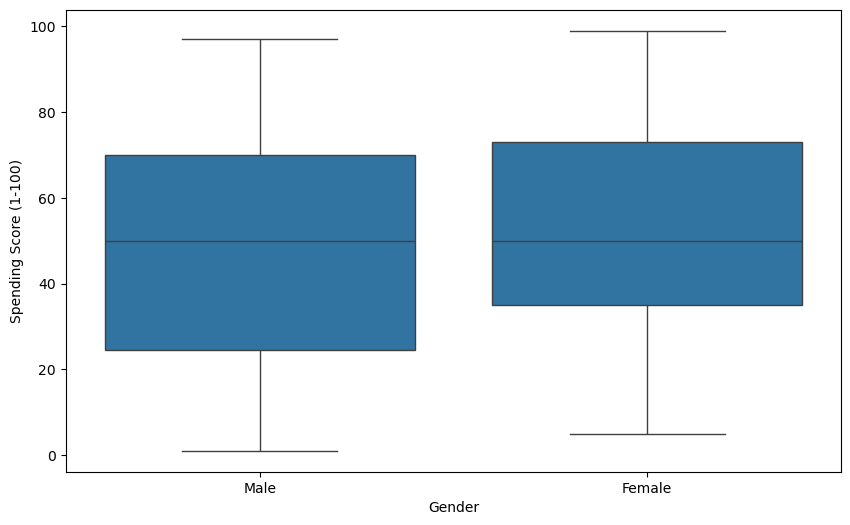

In [10]:
columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in columns:
  plt.figure(figsize=(10, 6))
  sns.boxplot(data=df, x='Gender', y=df[i])

In [11]:
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

# Bivariate Analysis

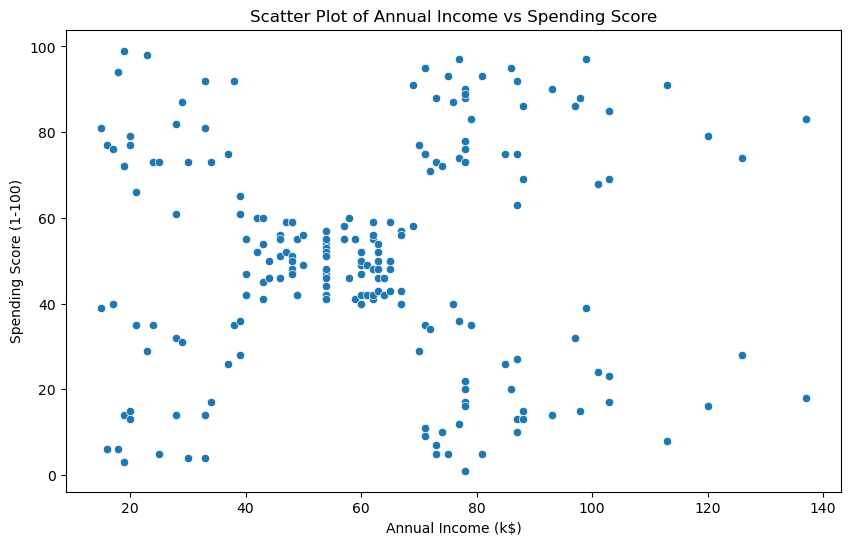

In [12]:
# use seaborn to plot scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title('Scatter Plot of Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

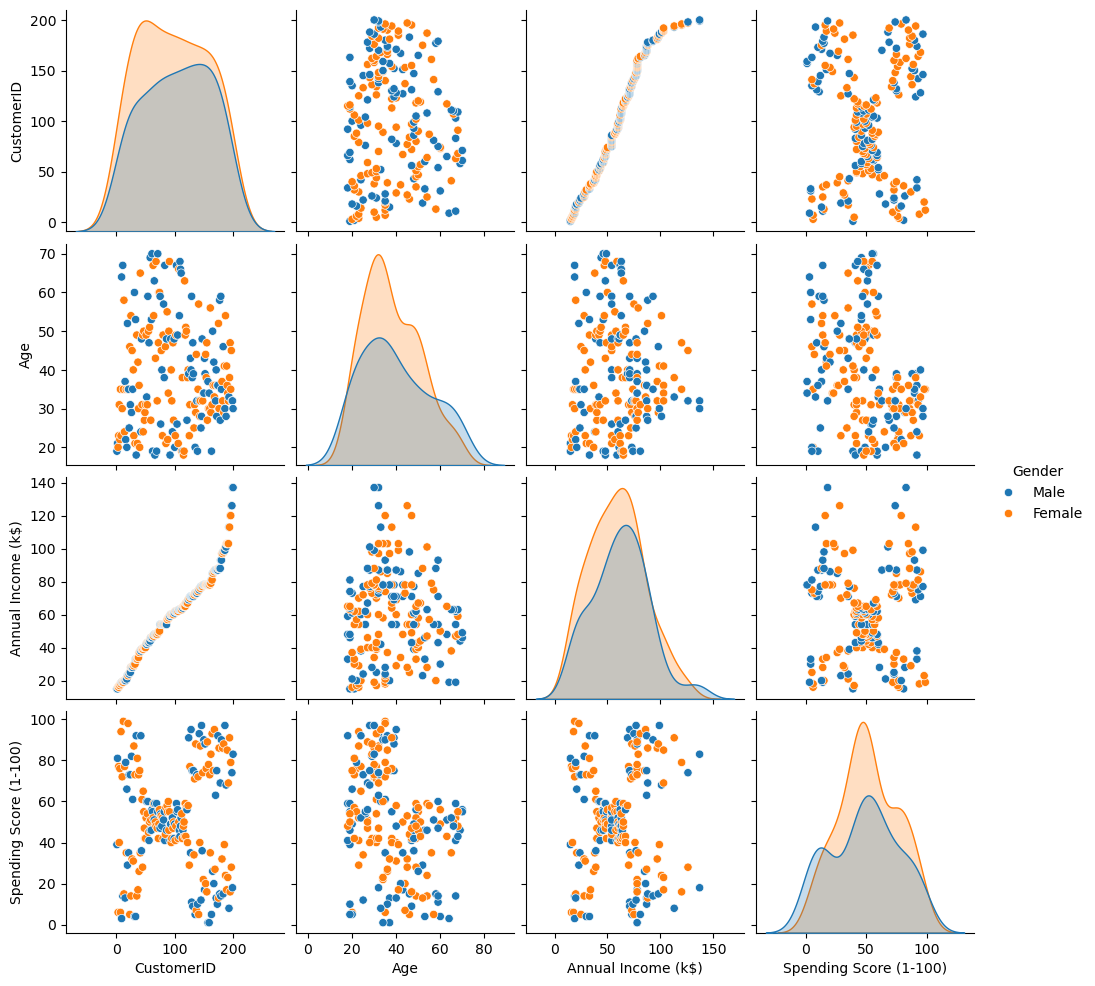

In [13]:
# use seaborn to plot pairplot
#df = df.drop('CustomerID', axis=1)
sns.pairplot(df, hue='Gender')
plt.show()

In [14]:
df.groupby(['Gender'])[['Age', 'Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [15]:
# display corr
df.drop('Gender', axis=1).corr()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


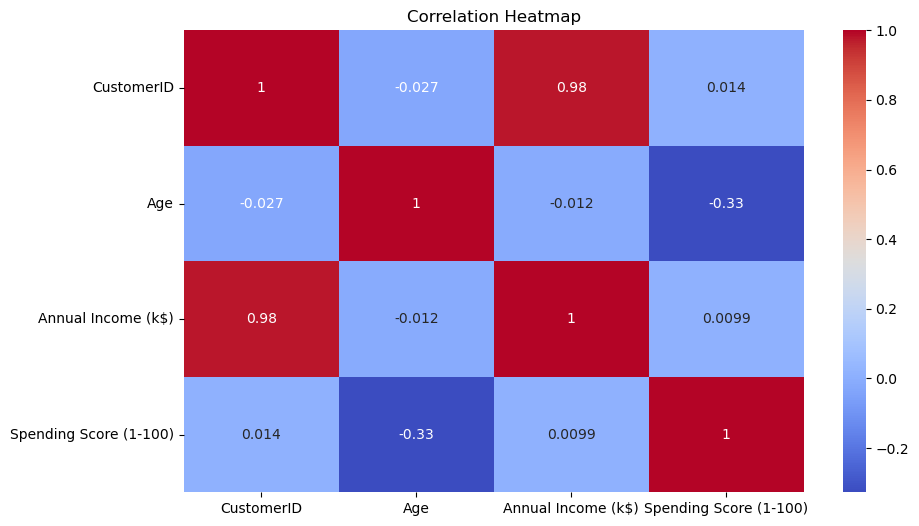

In [16]:
# plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop('Gender', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Clustering Bivariate (Annual Income vs Spending Score)

In [17]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [18]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [19]:
clustering2 = KMeans(n_clusters=5, random_state=42)

In [20]:
# fit the model
clustering2.fit(X)

KMeans(n_clusters=5, random_state=42)

In [21]:
clustering2.labels_

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

In [22]:
df['Annual Income vs Spending Cluster'] = clustering2.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Annual Income vs Spending Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [23]:
inertia_scores2 = []
for i in range(1, 11):
    kmeans2 = KMeans(n_clusters=i, random_state=42)
    kmeans2.fit(X)
    inertia_scores2.append(kmeans2.inertia_)

In [24]:
inertia_scores2

[269981.28,
 183653.3289473684,
 106348.37306211119,
 73880.64496247195,
 44448.45544793371,
 40825.16946386946,
 33642.579220779226,
 26686.83778518778,
 24766.471609793443,
 23103.122085983916]

Text(0, 0.5, 'Inertia')

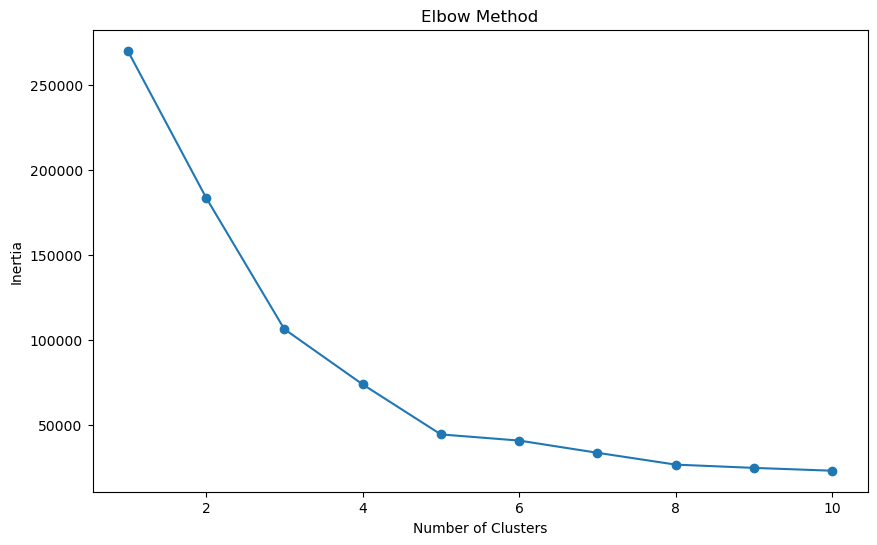

In [25]:
# plot inertia scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_scores2, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

## From the elbow curve, the optimum number of clusters is 5. This is where the elbow curves

In [26]:
# cluster centers
clustering2.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [27]:
# add to dataframe
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x', 'y']

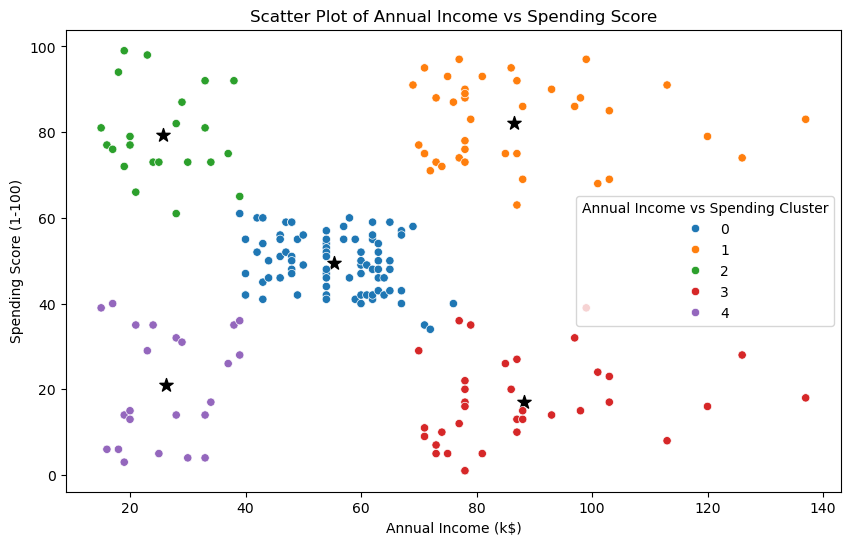

In [28]:
# Plot Scatter Plot of Annual Income vs Spending Score
plt.figure(figsize=(10, 6))
plt.scatter(x=centers['x'], y=centers['y'], marker='*', s=100, c='black')
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Annual Income vs Spending Cluster', palette='tab10')
plt.title('Scatter Plot of Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [29]:
# group by 'Annual Income vs Spending Cluster'
df.groupby(['Annual Income vs Spending Cluster'])[['Age', 'Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Annual Income vs Spending Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [30]:
y_means = clustering2.fit_predict(X)

In [31]:
# Make some predictions
clustering2.predict([[80, 20]])

array([3])

# Clustering Bivariate (Annual Income vs Spending Score)

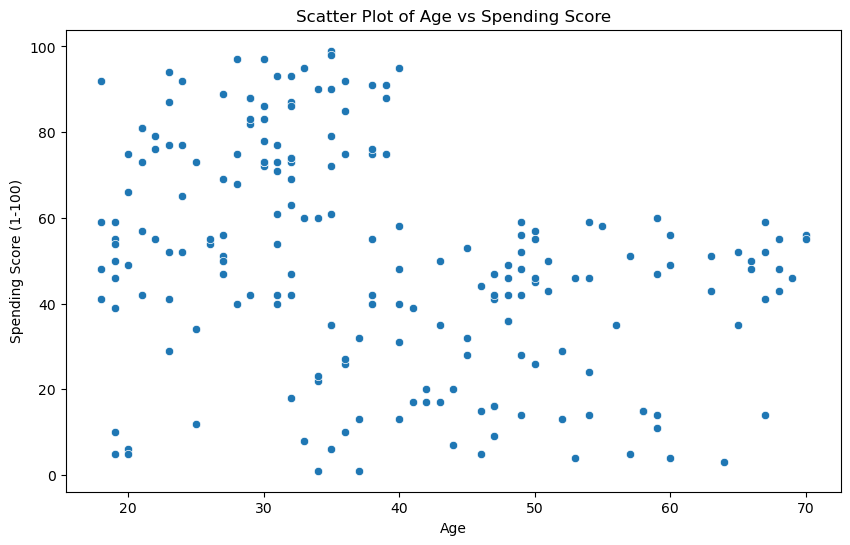

In [32]:
# use seaborn to plot scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)')
plt.title('Scatter Plot of Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [33]:
X = df[['Age', 'Spending Score (1-100)']]

In [34]:
inertia_scores = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    inertia_scores.append(kmeans.inertia_)

In [35]:
inertia_scores

[171535.5,
 75949.15601023019,
 45840.67661610867,
 28165.58356662934,
 23951.044340905453,
 20015.97945860015,
 18257.478685045746,
 13855.829804868808,
 13216.221407166293,
 10808.438587626972]

Text(0, 0.5, 'Inertia')

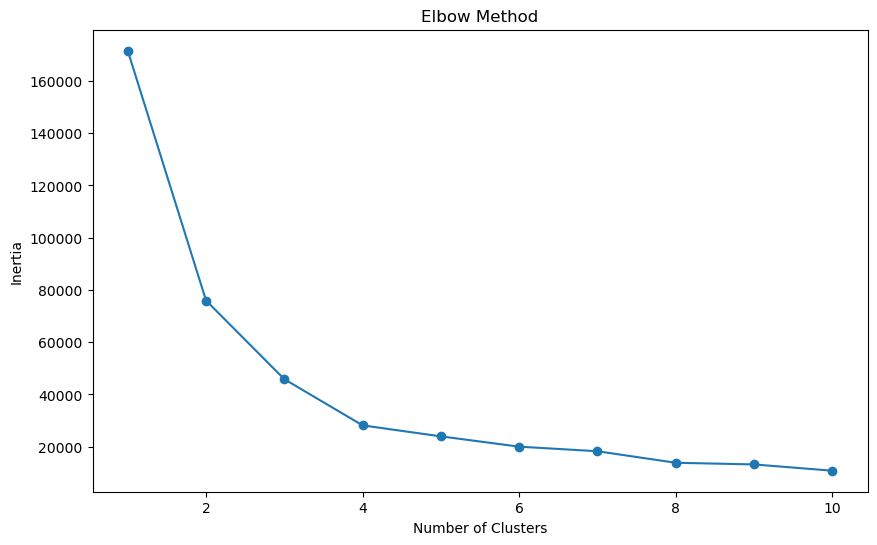

In [36]:
# plot inertia scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_scores, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

In [37]:
clustering = KMeans(n_clusters=4, random_state=42)

In [38]:
# fit the model
clustering.fit(X)

KMeans(n_clusters=4, random_state=42)

In [39]:
clustering.labels_

array([3, 1, 2, 1, 3, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 3, 3, 2, 1, 3, 1,
       2, 1, 2, 1, 2, 3, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 0, 3,
       2, 3, 0, 3, 3, 3, 0, 3, 3, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 0, 0, 3,
       0, 0, 3, 3, 0, 0, 0, 0, 0, 3, 0, 3, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3,
       3, 0, 0, 3, 0, 3, 3, 3, 0, 3, 0, 3, 3, 0, 0, 3, 0, 3, 0, 0, 0, 0,
       0, 3, 3, 3, 3, 3, 0, 0, 0, 0, 3, 3, 3, 1, 3, 1, 0, 1, 2, 1, 2, 1,
       3, 1, 2, 1, 2, 1, 2, 1, 2, 1, 3, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 3, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 3, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

In [40]:
# cluster centers
clustering.cluster_centers_

array([[55.70833333, 48.22916667],
       [30.1754386 , 82.35087719],
       [43.29166667, 15.02083333],
       [27.61702128, 49.14893617]])

In [41]:
# add to dataframe
centers1 = pd.DataFrame(clustering.cluster_centers_)
centers1.columns = ['x', 'y']

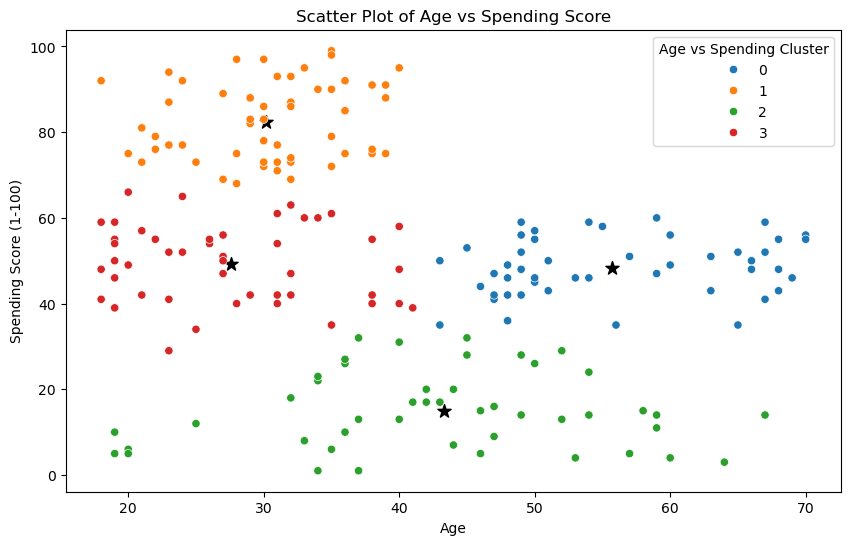

In [42]:
# Introduce centroids for each group in the scatter plot
df['Age vs Spending Cluster'] = clustering.labels_
plt.figure(figsize=(10, 6))
plt.scatter(x=centers1['x'], y=centers1['y'], marker='*', s=100, c='black')
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Age vs Spending Cluster', palette='tab10')
plt.title('Scatter Plot of Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [43]:
y_means = clustering.fit_predict(X)

In [44]:
# to some predictions
clustering.predict([[60, 50]])

array([0])

In [45]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Annual Income vs Spending Cluster,Age vs Spending Cluster
0,1,Male,19,15,39,4,3
1,2,Male,21,15,81,2,1
2,3,Female,20,16,6,4,2
3,4,Female,23,16,77,2,1
4,5,Female,31,17,40,4,3


k=2: silhouette score = 0.332
k=3: silhouette score = 0.336
k=4: silhouette score = 0.405
k=5: silhouette score = 0.358
k=6: silhouette score = 0.416
k=7: silhouette score = 0.442
k=8: silhouette score = 0.433
k=9: silhouette score = 0.409
k=10: silhouette score = 0.397


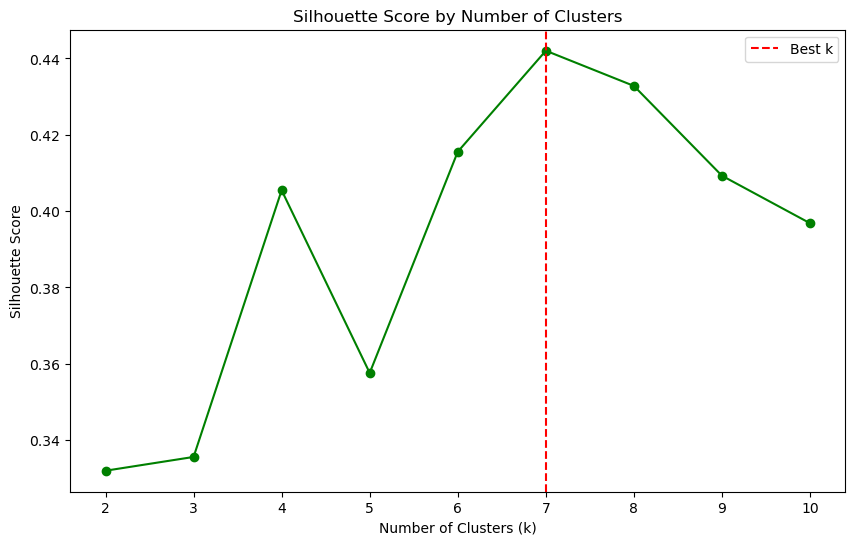

In [62]:
silhouette_scores = []
k_range = range(2, 11)  # silhouette score needs at least 2 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.3f}")

# Plot it next to your elbow chart
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.axvline(x=silhouette_scores.index(max(silhouette_scores)) + 2, color='red', linestyle='--', label='Best k')
plt.legend()
plt.show()

In [63]:
# Income vs Spending
X1 = df[['Annual Income (k$)', 'Spending Score (1-100)']]
labels1 = KMeans(n_clusters=5, random_state=42).fit_predict(X1)
print(f"Income vs Spending (k=5): {silhouette_score(X1, labels1):.3f}")

# Age vs Spending
X2 = df[['Age', 'Spending Score (1-100)']]
labels2 = KMeans(n_clusters=4, random_state=42).fit_predict(X2)
print(f"Age vs Spending (k=4): {silhouette_score(X2, labels2):.3f}")

Income vs Spending (k=5): 0.554
Age vs Spending (k=4): 0.500


## Streamlit Deployment

In [46]:
!pip install streamlit

In [47]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd

# Load the trained K-Means model
model = joblib.load('customer_segmentation')

# Define the function to make predictions
def predict_segment(annual_income, spending_score):
    """Predicts the customer segment based on Annual Income and Spending Score."""
    data = [[annual_income, spending_score]]
    segment = model.predict(data)[0]
    return segment

# Define the Streamlit app interface
st.title('Customer Segmentation Prediction')

st.write('Enter the customer\'s Annual Income and Spending Score to predict their segment.')

annual_income = st.number_input('Annual Income (k$)', min_value=0.0, value=50.0)
spending_score = st.number_input('Spending Score (1-100)', min_value=0.0, max_value=100.0, value=50.0)

if st.button('Predict'):
    segment = predict_segment(annual_income, spending_score)

    st.subheader('Prediction Result:')
    if segment == 0:
        st.write("This customer belongs to Cluster 0: Customers with Medium Annual Income and Medium Spending Score")
    elif segment == 1:
        st.write("This customer belongs to Cluster 1: Customers with High Annual Income and High Spending Score")
    elif segment == 2:
        st.write("This customer belongs to Cluster 2: Customers with Low Annual Income and High Spending Score")
    elif segment == 3:
        st.write("This customer belongs to Cluster 3: Customers with High Annual Income and Low Spending Score")
    elif segment == 4:
        st.write("This customer belongs to Cluster 4: Customers with Low Annual Income and Low Spending Score")

Writing app.py


In [48]:
!pip install streamlit pyngrok -q

In [50]:
!wget -q -O - ipv4.icanhazip.com

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [51]:
!streamlit run app.py & npx localtunnel --port 8501

^C
